In [28]:
import os
import scipy.sparse as sp
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [29]:
DATASET = "retinal"
BASE    = f"../../../data/processed/{DATASET}"

rna     = ad.read_h5ad(f"output/{DATASET}_with_networks_seed42.h5ad")
oob_df  = rna.obsm["wScReNI_oob_r2"]
cell_r2 = oob_df.mean(axis=1)

pr_df        = pd.read_csv(f"output/{DATASET}_multirun_precision_recall.csv")
mean_edge_var = np.load(f"output/{DATASET}_edge_variance.npy")


In [30]:
mean_pr = pr_df.groupby(pr_df.index % 400)[["precision", "recall"]].mean().reset_index(drop=True)
mean_pr["rf_r2"]         = cell_r2.values
mean_pr["edge_variance"] = mean_edge_var

mean_pr["f1"] = (
    2 * mean_pr["precision"] * mean_pr["recall"]
) / (mean_pr["precision"] + mean_pr["recall"])

print(mean_pr.describe())

        precision      recall       rf_r2  edge_variance          f1
count  400.000000  400.000000  400.000000   4.000000e+02  400.000000
mean     0.031851    0.178547   -0.112057   1.697048e-08    0.053826
std      0.005757    0.050545    0.023129   2.228741e-09    0.010257
min      0.018459    0.071574   -0.152509   1.179627e-08    0.029349
25%      0.028584    0.150076   -0.128009   1.578996e-08    0.048912
50%      0.033163    0.183243   -0.117128   1.718189e-08    0.056205
75%      0.035782    0.213382   -0.099829   1.843526e-08    0.060975
max      0.048411    0.285617   -0.012543   2.462672e-08    0.081042


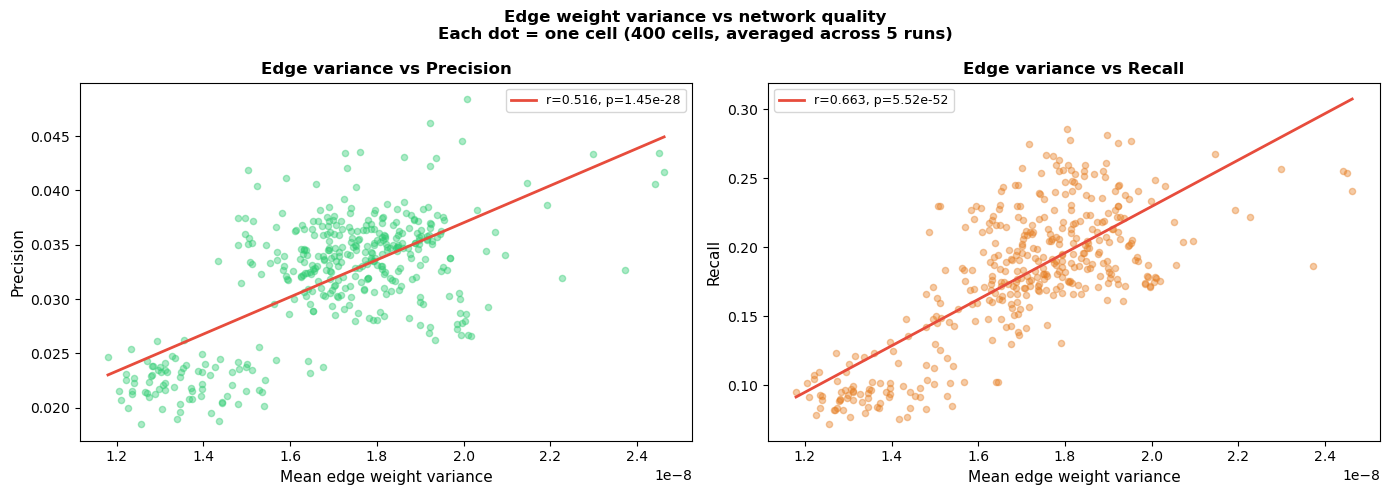

In [31]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, color in zip(axes, ["precision", "recall"], ["#2ecc71", "#e67e22"]):
    r, p = stats.spearmanr(mean_pr["edge_variance"], mean_pr[metric])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(mean_pr["edge_variance"], mean_pr[metric],
               alpha=0.4, s=20, color=color)

    slope, intercept, _, _, _ = stats.linregress(
        mean_pr["edge_variance"], mean_pr[metric]
    )
    x = np.linspace(mean_pr["edge_variance"].min(),
                    mean_pr["edge_variance"].max(), 100)
    ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel("Mean edge weight variance", fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f"Edge variance vs {metric.capitalize()}", fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle(
    "Edge weight variance vs network quality\n"
    "Each dot = one cell (400 cells, averaged across 5 runs)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("edge_var_vs_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

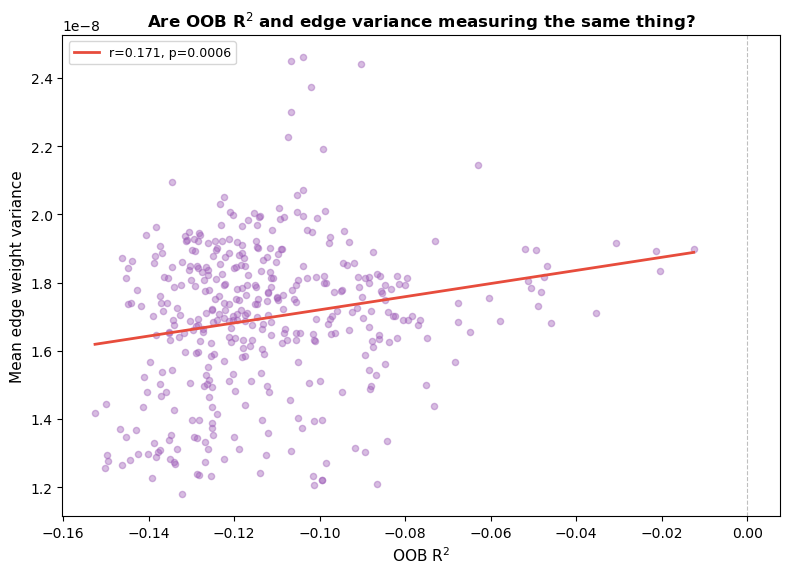

In [32]:
r, p = stats.spearmanr(mean_pr["rf_r2"], mean_pr["edge_variance"])
p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mean_pr["rf_r2"], mean_pr["edge_variance"],
           alpha=0.4, s=20, color="#9b59b6")

slope, intercept, _, _, _ = stats.linregress(
    mean_pr["rf_r2"], mean_pr["edge_variance"]
)
x = np.linspace(mean_pr["rf_r2"].min(), mean_pr["rf_r2"].max(), 100)
ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
        label=f"r={r:.3f}, p={p_str}")

ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("OOB R$^2$", fontsize=11)
ax.set_ylabel("Mean edge weight variance", fontsize=11)
ax.set_title("Are OOB R$^2$ and edge variance measuring the same thing?",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("r2_vs_edge_variance.png", dpi=150, bbox_inches="tight")
plt.show()


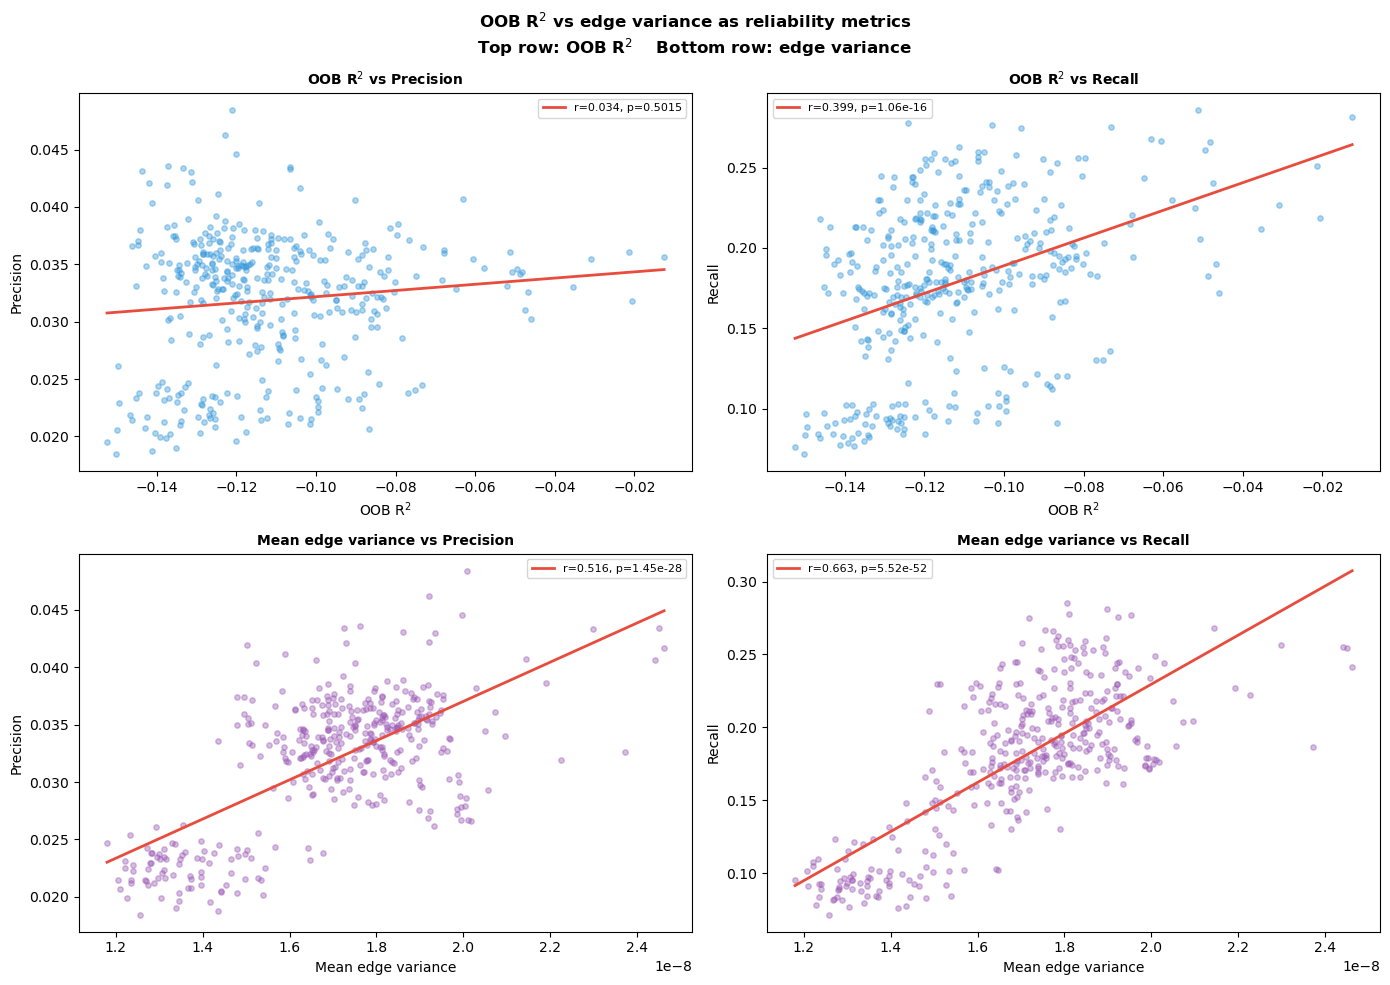

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    ("rf_r2",         "precision", "#3498db", "#2ecc71"),
    ("rf_r2",         "recall",    "#3498db", "#e67e22"),
    ("edge_variance", "precision", "#9b59b6", "#2ecc71"),
    ("edge_variance", "recall",    "#9b59b6", "#e67e22"),
]

xlabels = {
    "rf_r2":         "OOB R$^2$",
    "edge_variance": "Mean edge variance",
}

for ax, (x_col, y_col, x_color, y_color) in zip(axes.flat, pairs):
    r, p = stats.spearmanr(mean_pr[x_col], mean_pr[y_col])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(mean_pr[x_col], mean_pr[y_col],
               alpha=0.4, s=15, color=x_color)

    slope, intercept, _, _, _ = stats.linregress(
        mean_pr[x_col], mean_pr[y_col]
    )
    x = np.linspace(mean_pr[x_col].min(), mean_pr[x_col].max(), 100)
    ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel(xlabels[x_col], fontsize=10)
    ax.set_ylabel(y_col.capitalize(), fontsize=10)
    ax.set_title(f"{xlabels[x_col]} vs {y_col.capitalize()}",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle(
    "OOB R$^2$ vs edge variance as reliability metrics\n"
    "Top row: OOB R$^2$    Bottom row: edge variance",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("metric_comparison_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
print("\n" + "="*55)
print("Summary: Spearman correlations with network quality")
print("="*55)
for x_col, x_label in [("rf_r2", "OOB R$^2$"), ("edge_variance", "Edge variance")]:
    print(f"\n{x_label}:")
    for metric in ["precision", "recall"]:
        r, p = stats.spearmanr(mean_pr[x_col], mean_pr[metric])
        print(f"  {metric:10s}: r={r:.4f}, p={p:.2e}")


Summary: Spearman correlations with network quality

OOB R$^2$:
  precision : r=0.0337, p=5.01e-01
  recall    : r=0.3988, p=1.06e-16

Edge variance:
  precision : r=0.5157, p=1.45e-28
  recall    : r=0.6630, p=5.52e-52


In [35]:
networks = np.load(f"output/{DATASET}_networks_seed42.npy")   
density  = np.array([(networks[i] > 0).sum() for i in range(400)])

print("Edge variance vs density:")
r, p = stats.spearmanr(mean_edge_var, density)
print(f"  r={r:.4f}, p={p:.2e}")

print("\nOOB R$^2$ vs density:")
r, p = stats.spearmanr(cell_r2.values, density)
print(f"  r={r:.4f}, p={p:.2e}")

Edge variance vs density:
  r=0.5977, p=4.28e-40

OOB R$^2$ vs density:
  r=0.5494, p=6.48e-33


In [36]:
mean_weight  = np.array([networks[i].mean() for i in range(400)])
norm_variance = mean_edge_var / (mean_weight + 1e-12)

r, p = stats.spearmanr(norm_variance, density)
print(f"Normalised variance vs density: r={r:.4f}, p={p:.2e}")

Normalised variance vs density: r=-0.3907, p=4.85e-16


In [37]:
data         = np.load(f"output/{DATASET}_multirun.npz")
all_networks = data["networks"]

edge_mean = all_networks.mean(axis=0)
edge_std  = all_networks.std(axis=0)
edge_cv   = edge_std / (edge_mean + 1e-12)
mean_cv   = edge_cv.mean(axis=(1,2))

r, p = stats.spearmanr(mean_cv, density)
print(f"CV vs density: r={r:.4f}, p={p:.2e}")

CV vs density: r=0.9809, p=5.66e-285


In [38]:
mean_pr["norm_variance"] = norm_variance
mean_pr["density"] = density

print("Normalised variance vs precision/recall:")
for metric in ["precision", "recall"]:
    r, p = stats.spearmanr(norm_variance, mean_pr[metric])
    print(f"  {metric:10s}: r={r:.4f}, p={p:.2e}")

print("\nSummary:")
print(f"{'Metric':<20} {'Precision r':>12} {'Recall r':>10}")
print("-" * 45)
for col, label in [("rf_r2", "OOB R$^2$"),
                   ("edge_variance", "Edge variance"),
                   ("norm_variance", "Norm variance")]:
    r_p, _ = stats.spearmanr(mean_pr[col], mean_pr["precision"])
    r_r, _ = stats.spearmanr(mean_pr[col], mean_pr["recall"])
    print(f"{label:<20} {r_p:>12.4f} {r_r:>10.4f}")

Normalised variance vs precision/recall:
  precision : r=0.2888, p=4.00e-09
  recall    : r=-0.1901, p=1.31e-04

Summary:
Metric                Precision r   Recall r
---------------------------------------------
OOB R$^2$                  0.0337     0.3988
Edge variance              0.5157     0.6630
Norm variance              0.2888    -0.1901


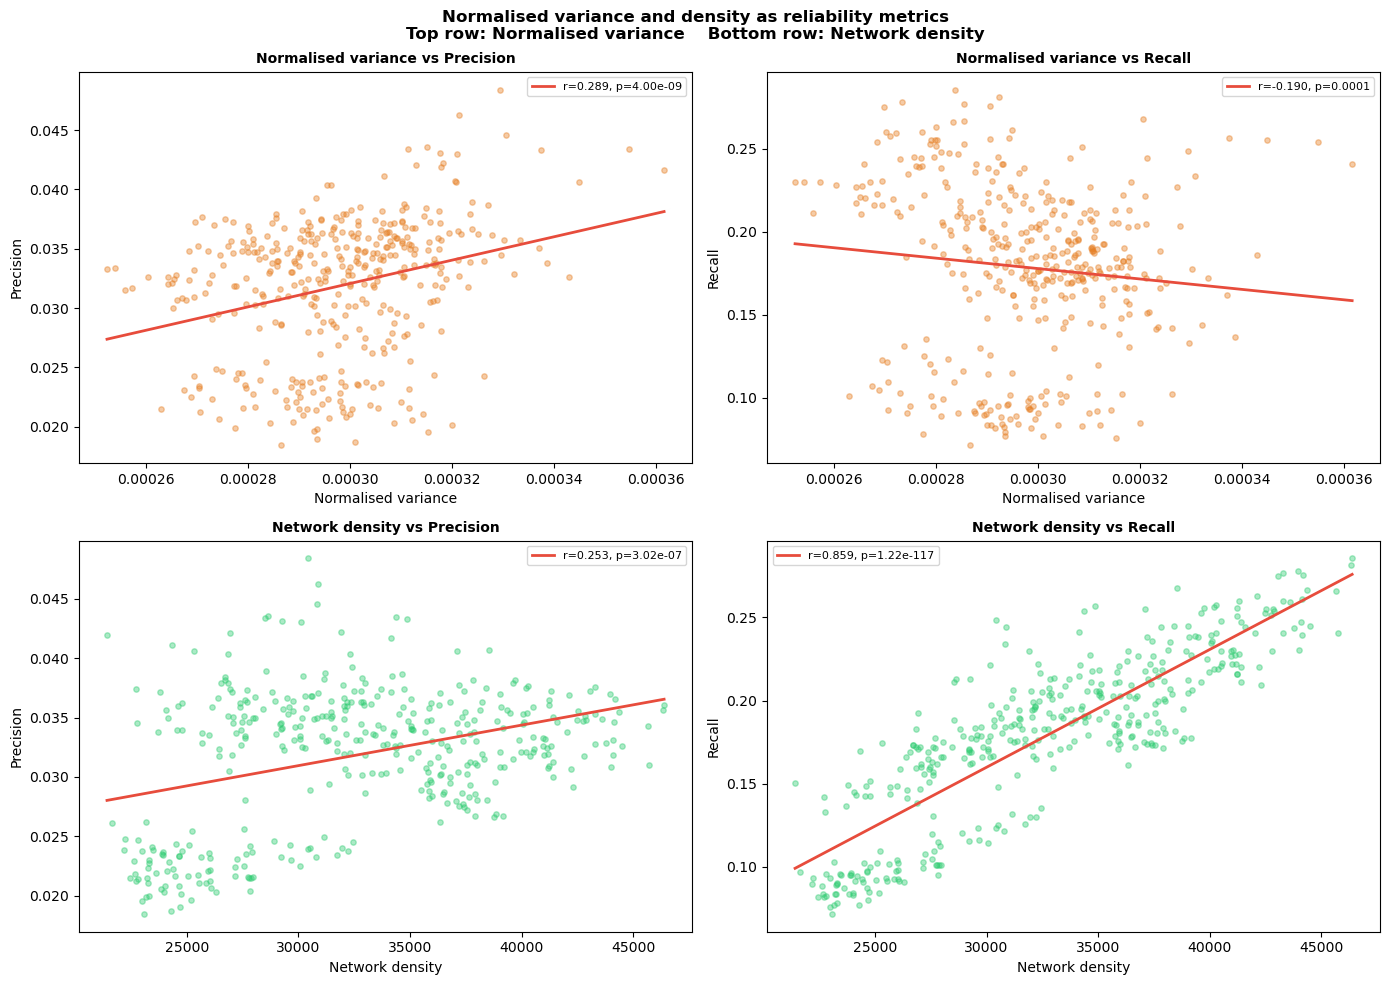

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    ("norm_variance", "precision", "#e67e22", "#2ecc71"),
    ("norm_variance", "recall",    "#e67e22", "#e67e22"),
    ("density",       "precision", "#2ecc71", "#2ecc71"),
    ("density",       "recall",    "#2ecc71", "#e67e22"),
]

xlabels = {
    "norm_variance": "Normalised variance",
    "density":       "Network density",
}

for ax, (x_col, y_col, x_color, y_color) in zip(axes.flat, pairs):
    r, p = stats.spearmanr(mean_pr[x_col], mean_pr[y_col])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(mean_pr[x_col], mean_pr[y_col],
               alpha=0.4, s=15, color=x_color)

    slope, intercept, _, _, _ = stats.linregress(
        mean_pr[x_col], mean_pr[y_col]
    )
    x = np.linspace(mean_pr[x_col].min(), mean_pr[x_col].max(), 100)
    ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel(xlabels[x_col], fontsize=10)
    ax.set_ylabel(y_col.capitalize(), fontsize=10)
    ax.set_title(f"{xlabels[x_col]} vs {y_col.capitalize()}",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle(
    "Normalised variance and density as reliability metrics\n"
    "Top row: Normalised variance    Bottom row: Network density",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("norm_var_density_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

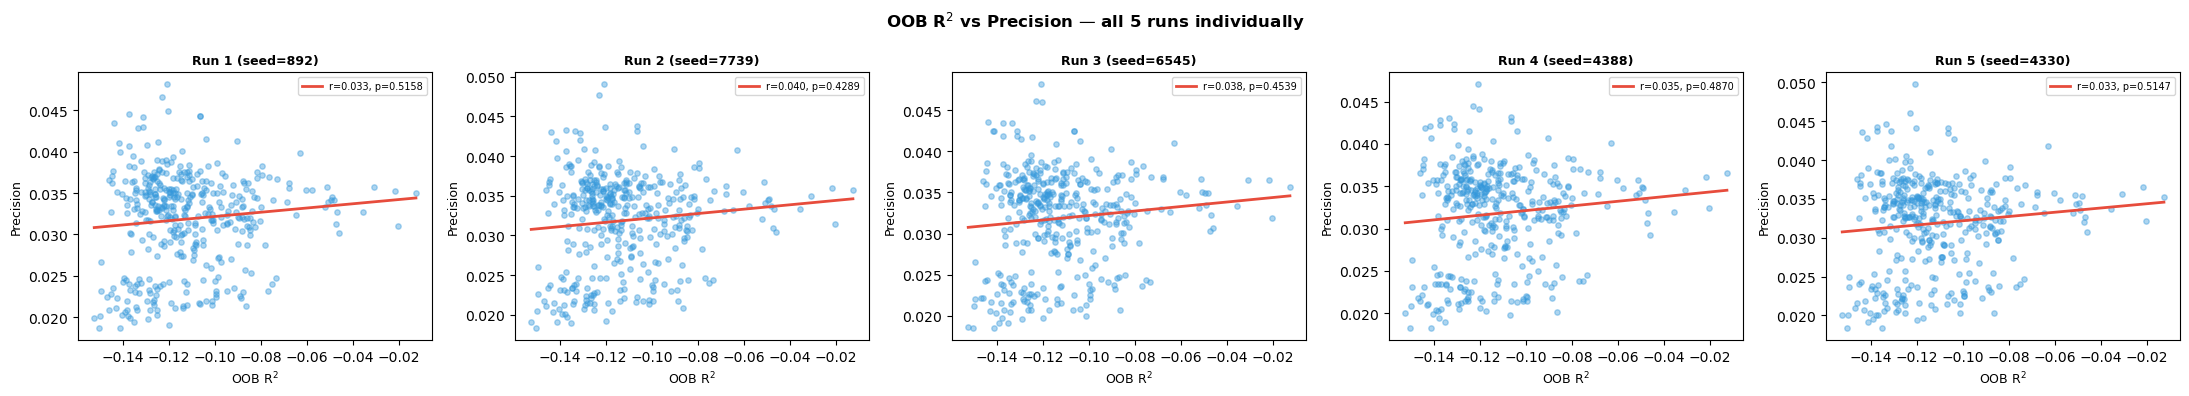

OOB R$^2$ vs Precision per run:
  Run 1 (seed=892): r=0.0326, p=5.16e-01
  Run 2 (seed=7739): r=0.0397, p=4.29e-01
  Run 3 (seed=6545): r=0.0375, p=4.54e-01
  Run 4 (seed=4388): r=0.0349, p=4.87e-01
  Run 5 (seed=4330): r=0.0327, p=5.15e-01


In [40]:
seeds = data["seeds"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i in range(5):
    ax = axes[i]

    run_pr = pr_df[pr_df["run"] == i].reset_index(drop=True)

    r, p = stats.spearmanr(cell_r2.values, run_pr["precision"])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(cell_r2.values, run_pr["precision"],
               alpha=0.4, s=15, color="#3498db")

    slope, intercept, _, _, _ = stats.linregress(cell_r2.values, run_pr["precision"])
    x = np.linspace(cell_r2.min(), cell_r2.max(), 100)
    ax.plot(x, slope*x + intercept, color="#e74c3c", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel("OOB R$^2$", fontsize=9)
    ax.set_ylabel("Precision", fontsize=9)
    ax.set_title(f"Run {i+1} (seed={seeds[i]})", fontweight="bold", fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle("OOB R$^2$ vs Precision — all 5 runs individually",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("oob_vs_precision_per_run.png", dpi=150, bbox_inches="tight")
plt.show()

print("OOB R$^2$ vs Precision per run:")
for i in range(5):
    run_pr = pr_df[pr_df["run"] == i].reset_index(drop=True)
    r, p = stats.spearmanr(cell_r2.values, run_pr["precision"])
    print(f"  Run {i+1} (seed={seeds[i]}): r={r:.4f}, p={p:.2e}")

In [41]:
rna = ad.read_h5ad(f"output/{DATASET}_with_networks.h5ad")

X = rna.X.toarray() if sp.issparse(rna.X) else rna.X
expr_df = pd.DataFrame(
    X.T,                        
    index   = rna.var_names,
    columns = rna.obs_names,
)


mean_expression = expr_df.mean(axis=0).values   
total_expression = expr_df.sum(axis=0).values   

nonzero_fraction = (expr_df > 0).mean(axis=0).values  

mean_pr["mean_expression"]  = mean_expression
mean_pr["total_expression"] = total_expression
mean_pr["nonzero_fraction"] = nonzero_fraction

print("Correlations with mean expression:")
for col, label in [
    ("density",       "Density"),
    ("edge_variance", "Edge variance"),
    ("rf_r2",         "OOB R$^2$"),
    ("norm_variance", "Norm variance"),
    ("precision",     "Precision"),
    ("recall",        "Recall"),
]:
    r, p = stats.spearmanr(mean_expression, mean_pr[col])
    print(f"  {label:20s}: r={r:.4f}, p={p:.2e}")

print("\nCorrelations with non-zero fraction (sparsity):")
for col, label in [
    ("density",       "Density"),
    ("edge_variance", "Edge variance"),
    ("rf_r2",         "OOB R$^2$"),
    ("norm_variance", "Norm variance"),
    ("precision",     "Precision"),
    ("recall",        "Recall"),
]:
    r, p = stats.spearmanr(nonzero_fraction, mean_pr[col])
    print(f"  {label:20s}: r={r:.4f}, p={p:.2e}")

Correlations with mean expression:
  Density             : r=0.7436, p=1.40e-71
  Edge variance       : r=0.2344, p=2.13e-06
  OOB R$^2$           : r=0.4055, p=2.89e-17
  Norm variance       : r=-0.5587, p=3.32e-34
  Precision           : r=-0.0506, p=3.13e-01
  Recall              : r=0.5490, p=7.33e-33

Correlations with non-zero fraction (sparsity):
  Density             : r=0.8073, p=3.35e-93
  Edge variance       : r=0.2707, p=3.81e-08
  OOB R$^2$           : r=0.4509, p=1.98e-21
  Norm variance       : r=-0.5840, p=6.11e-38
  Precision           : r=-0.0133, p=7.91e-01
  Recall              : r=0.6112, p=2.42e-42


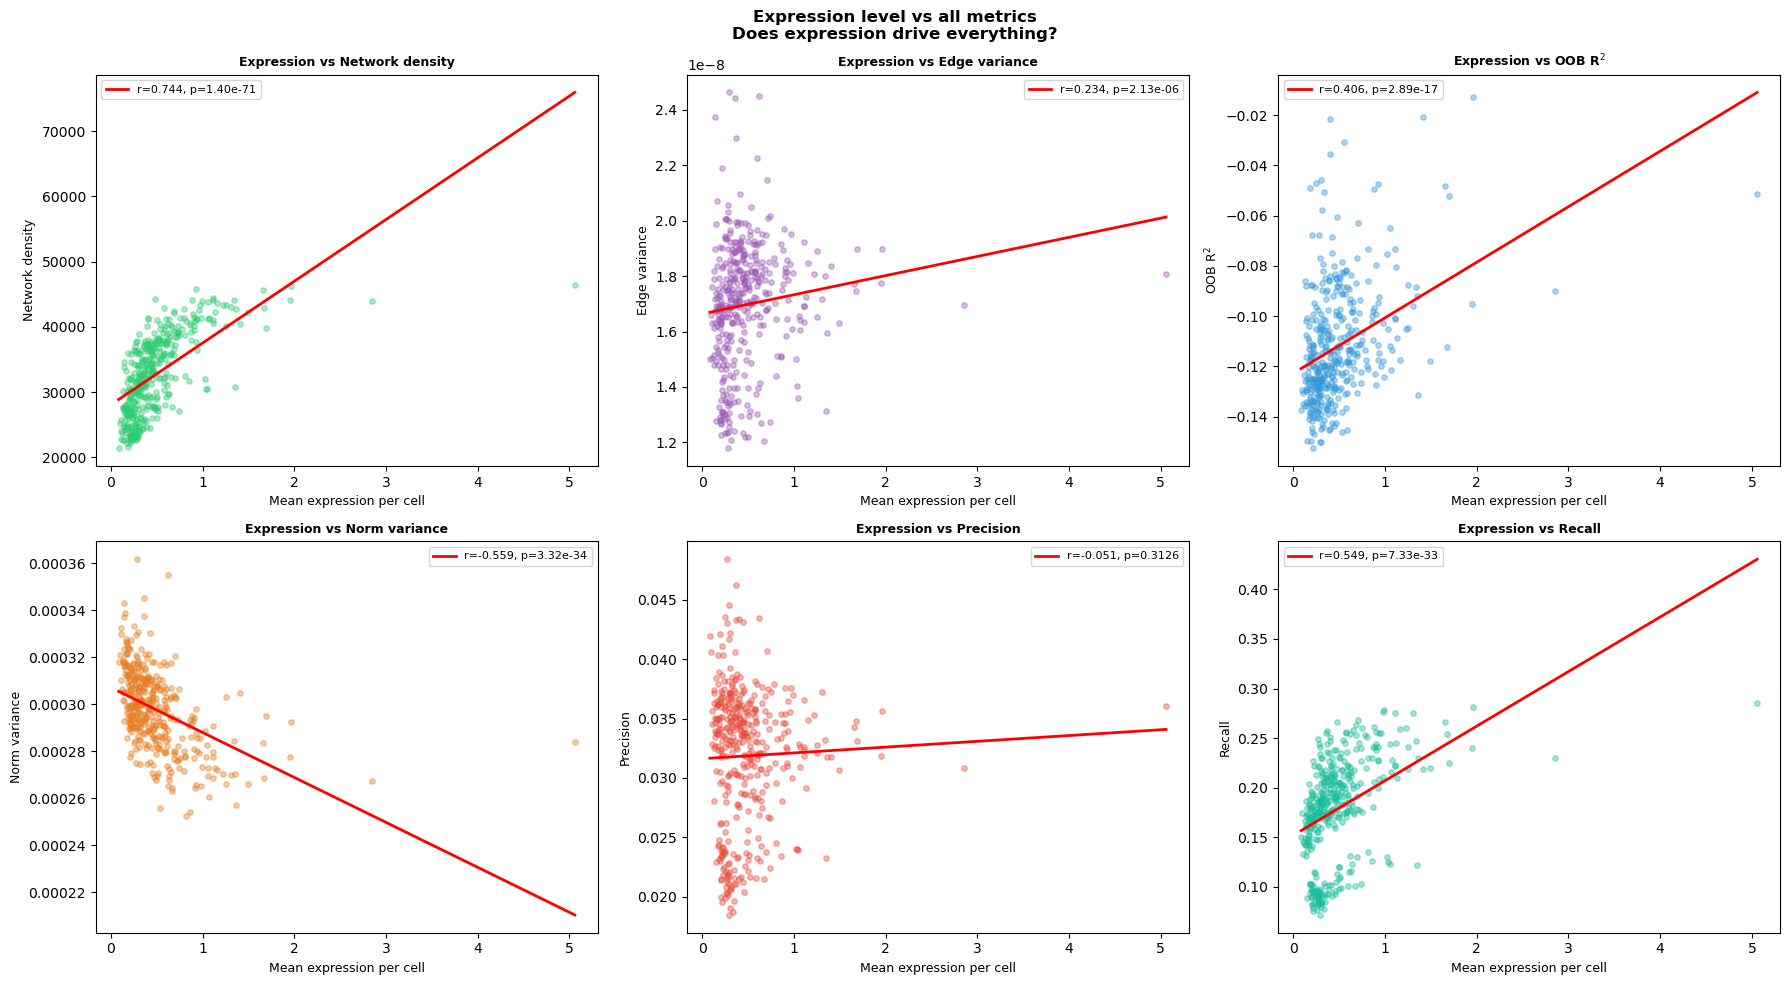

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ("density",       "Network density",   "#2ecc71"),
    ("edge_variance", "Edge variance",      "#9b59b6"),
    ("rf_r2",         "OOB R$^2$",            "#3498db"),
    ("norm_variance", "Norm variance",      "#e67e22"),
    ("precision",     "Precision",          "#e74c3c"),
    ("recall",        "Recall",             "#1abc9c"),
]

for ax, (col, label, color) in zip(axes.flat, metrics):
    r, p = stats.spearmanr(mean_expression, mean_pr[col])
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(mean_expression, mean_pr[col],
               alpha=0.4, s=15, color=color)

    slope, intercept, _, _, _ = stats.linregress(mean_expression, mean_pr[col])
    x = np.linspace(mean_expression.min(), mean_expression.max(), 100)
    ax.plot(x, slope*x + intercept, color="red", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel("Mean expression per cell", fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(f"Expression vs {label}", fontweight="bold", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle(
    "Expression level vs all metrics\n"
    "Does expression drive everything?",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("expression_vs_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
import pingouin as pg

mean_pr["density"]       = density
mean_pr["edge_variance"] = mean_edge_var
mean_pr["norm_variance"] = norm_variance
mean_pr["mean_expression"] = mean_expression

print("Partial correlations controlling for density:")
print("-" * 55)
for x_col, label in [("rf_r2",         "OOB R$^2$"),
                      ("edge_variance", "Edge variance"),
                      ("norm_variance", "Norm variance")]:
    for outcome in ["precision", "recall"]:
        result = pg.partial_corr(
            data   = mean_pr,
            x      = x_col,
            y      = outcome,
            covar  = "density",
            method = "spearman"
        )
        r = result["r"].values[0]
        p = result["p_val"].values[0]
        p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"
        print(f"  {label:20s} vs {outcome:10s}: r={r:.4f}, p={p_str}")

print("\nPartial correlations controlling for expression:")
print("-" * 55)
for x_col, label in [("rf_r2",         "OOB R$^2$"),
                      ("edge_variance", "Edge variance"),
                      ("norm_variance", "Norm variance")]:
    for outcome in ["precision", "recall"]:
        result = pg.partial_corr(
            data   = mean_pr,
            x      = x_col,
            y      = outcome,
            covar  = "mean_expression",
            method = "spearman"
        )
        r = result["r"].values[0]
        p = result["p_val"].values[0]
        p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"
        print(f"  {label:20s} vs {outcome:10s}: r={r:.4f}, p={p_str}")

Partial correlations controlling for density:
-------------------------------------------------------
  OOB R$^2$            vs precision : r=-0.1300, p=0.0093
  OOB R$^2$            vs recall    : r=-0.1704, p=0.0006
  Edge variance        vs precision : r=0.4701, p=2.48e-23
  Edge variance        vs recall    : r=0.3645, p=5.59e-14
  Norm variance        vs precision : r=0.4352, p=7.25e-20
  Norm variance        vs recall    : r=0.3084, p=3.09e-10

Partial correlations controlling for expression:
-------------------------------------------------------
  OOB R$^2$            vs precision : r=0.0594, p=0.2364
  OOB R$^2$            vs recall    : r=0.2306, p=3.25e-06
  Edge variance        vs precision : r=0.5434, p=4.93e-32
  Edge variance        vs recall    : r=0.6575, p=9.37e-51
  Norm variance        vs precision : r=0.3145, p=1.30e-10
  Norm variance        vs recall    : r=0.1682, p=0.0007


In [44]:
import pandas as pd
from scipy import stats
import pingouin as pg

metrics = [
    ("rf_r2",         "OOB R$^2$"),
    ("edge_variance", "Edge variance"),
    ("norm_variance", "Norm variance"),
    ("density",       "Network density"),
]

rows = []
for col, label in metrics:
    r_prec,  p_prec  = stats.spearmanr(mean_pr[col], mean_pr["precision"])
    r_rec,   p_rec   = stats.spearmanr(mean_pr[col], mean_pr["recall"])
    r_dens,  p_dens  = stats.spearmanr(mean_pr[col], mean_pr["density"]) if col != "density" else (1.0, 0.0)
    r_expr,  p_expr  = stats.spearmanr(mean_pr[col], mean_pr["mean_expression"])

    if col != "density":
        pc_prec = pg.partial_corr(data=mean_pr, x=col, y="precision", covar="density", method="spearman")
        pc_rec  = pg.partial_corr(data=mean_pr, x=col, y="recall",    covar="density", method="spearman")
        r_prec_pd = pc_prec["r"].values[0];  p_prec_pd = pc_prec["p_val"].values[0]
        r_rec_pd  = pc_rec["r"].values[0];   p_rec_pd  = pc_rec["p_val"].values[0]
    else:
        r_prec_pd = r_rec_pd = p_prec_pd = p_rec_pd = float("nan")

    def fmt(r, p):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        return f"{r:.3f} ({sig})"

    rows.append({
        "Metric":                        label,
        "vs Precision":                  fmt(r_prec,    p_prec),
        "vs Recall":                     fmt(r_rec,     p_rec),
        "vs Density":                    fmt(r_dens,    p_dens)    if col != "density" else "—",
        "vs Expression":                 fmt(r_expr,    p_expr),
        "vs Precision (ctrl density)":   fmt(r_prec_pd, p_prec_pd) if col != "density" else "—",
        "vs Recall (ctrl density)":      fmt(r_rec_pd,  p_rec_pd)  if col != "density" else "—",
    })

df_summary = pd.DataFrame(rows).set_index("Metric")
print(df_summary.to_string())
df_summary.to_csv("output/metric_summary_table.csv")

                vs Precision     vs Recall    vs Density vs Expression vs Precision (ctrl density) vs Recall (ctrl density)
Metric                                                                                                                     
OOB R$^2$         0.034 (ns)   0.399 (***)   0.549 (***)   0.406 (***)                 -0.130 (**)             -0.170 (***)
Edge variance    0.516 (***)   0.663 (***)   0.598 (***)   0.234 (***)                 0.470 (***)              0.364 (***)
Norm variance    0.289 (***)  -0.190 (***)  -0.391 (***)  -0.559 (***)                 0.435 (***)              0.308 (***)
Network density  0.253 (***)   0.859 (***)             —   0.744 (***)                           —                        —


C:\Users\Edi\AppData\Local\Temp\ipykernel_34588\695622712.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  list(cm.get_cmap("tab10").colors) +
C:\Users\Edi\AppData\Local\Temp\ipykernel_34588\695622712.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  list(cm.get_cmap("Set2").colors) +
C:\Users\Edi\AppData\Local\Temp\ipykernel_34588\695622712.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  list(cm.get_cmap("Dark2").colors)


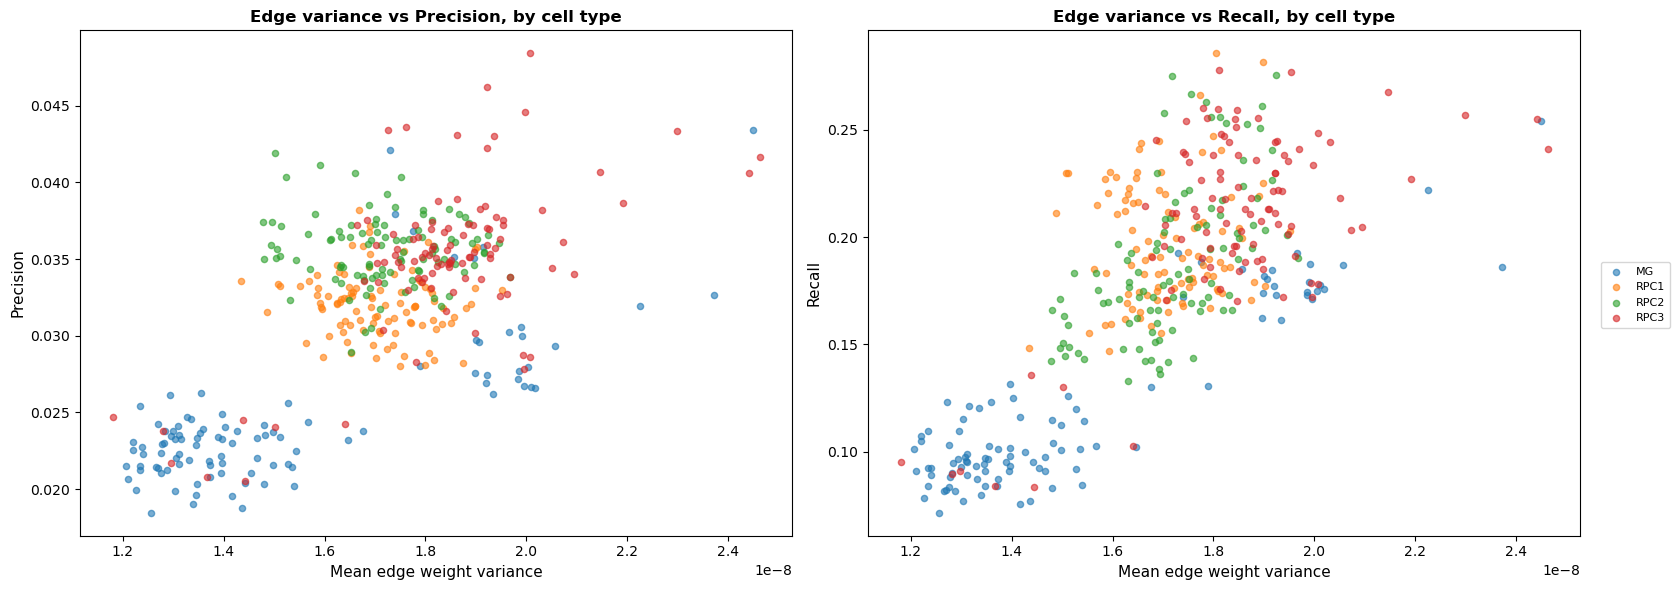

In [45]:

cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

colors_list = (
    list(cm.get_cmap("tab10").colors) +     
    list(cm.get_cmap("Set2").colors) +        
    list(cm.get_cmap("Dark2").colors)         
)

unique_types = sorted(cell_type.dropna().unique())


type_to_color = {ct: colors_list[i % len(colors_list)] for i, ct in enumerate(unique_types)}

colors = [type_to_color.get(ct, (0.5, 0.5, 0.5, 1)) for ct in cell_type]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ["precision", "recall"]):
    for ct in unique_types:
        mask = cell_type == ct
        ax.scatter(mean_pr.loc[mask.values, "edge_variance"],
                   mean_pr.loc[mask.values, metric],
                   color=type_to_color[ct], label=ct, alpha=0.6, s=20)

    ax.set_xlabel("Mean edge weight variance", fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f"Edge variance vs {metric.capitalize()}, by cell type", fontweight="bold")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           fontsize=8, ncol=1)

plt.tight_layout()
plt.savefig("edge_var_vs_precision_recall_by_celltype.png", dpi=150, bbox_inches="tight")
plt.show()

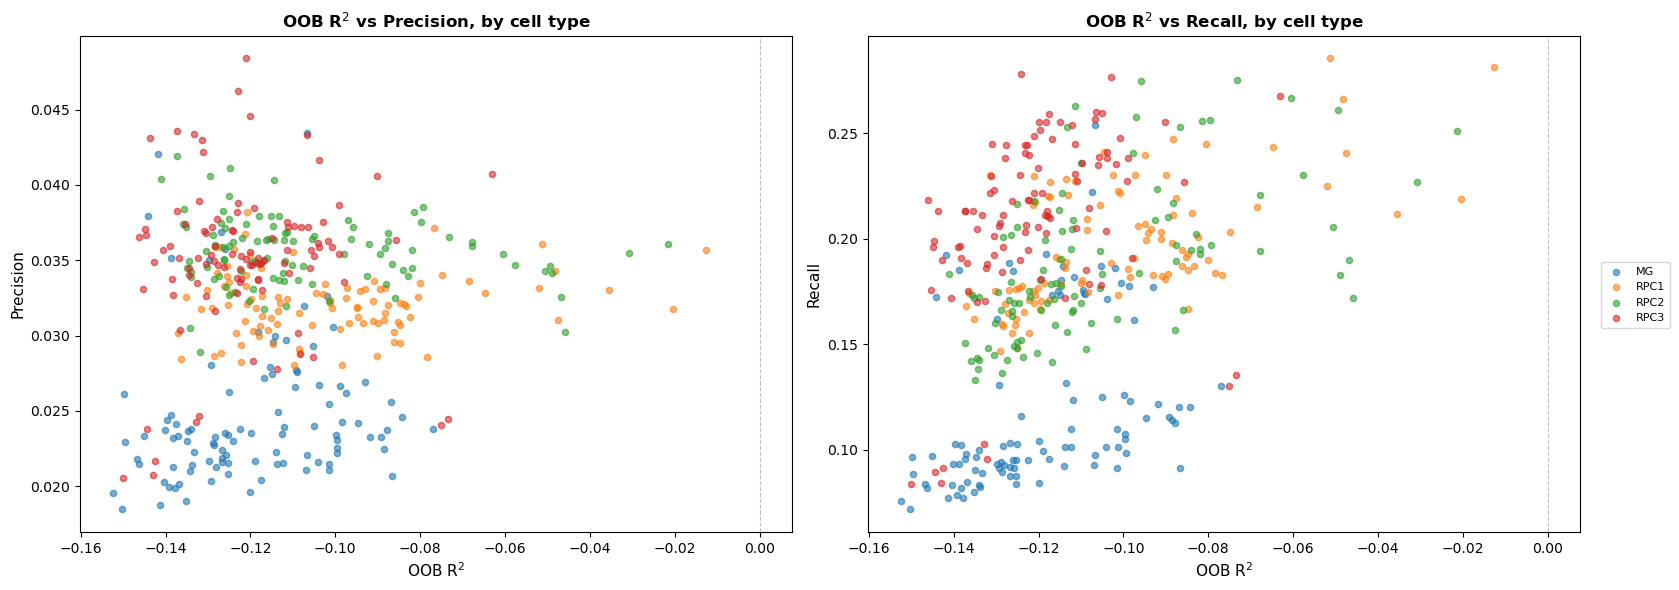

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ["precision", "recall"]):
    for ct in unique_types:
        mask = cell_type == ct
        ax.scatter(mean_pr.loc[mask.values, "rf_r2"],
                   mean_pr.loc[mask.values, metric],
                   color=type_to_color[ct], label=ct, alpha=0.6, s=20)

    ax.set_xlabel("OOB R$^2$", fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f"OOB R$^2$ vs {metric.capitalize()}, by cell type", fontweight="bold")
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           fontsize=8, ncol=1)

plt.tight_layout()
plt.savefig("oob_vs_precision_recall_by_celltype.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
edge_var_df = pd.DataFrame({
    "edge_variance": mean_edge_var,
    "cell_type":     cell_type.values,
})

summary = edge_var_df.groupby("cell_type")["edge_variance"].agg(["count", "mean", "std", "min", "max"])
print(summary.sort_values("count", ascending=False))

           count          mean           std           min           max
cell_type                                                               
MG           100  1.523115e-08  2.941055e-09  1.206093e-08  2.450119e-08
RPC1         100  1.707127e-08  1.002890e-09  1.434342e-08  1.952631e-08
RPC2         100  1.717029e-08  1.188142e-09  1.478679e-08  1.968108e-08
RPC3         100  1.840921e-08  1.937816e-09  1.179627e-08  2.462672e-08


C:\Users\Edi\AppData\Local\Temp\ipykernel_34588\4068408247.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = edge_var_df.groupby("cell_type")["edge_variance"].agg(["count", "mean", "std", "min", "max"])


In [48]:
def pairwise_correlations(nets, threshold=0.0):
    n = len(nets)
    corrs = []
    for i in range(n):
        for j in range(i+1, n):
            mask = (nets[i] > threshold) | (nets[j] > threshold)
            if mask.sum() == 0:
                continue
            c = np.corrcoef(nets[i][mask], nets[j][mask])[0, 1]
            corrs.append(c)
    return np.array(corrs)


def binarise(net, threshold=None, top_k=None):
    if top_k is not None:
        flat = net.flatten()
        threshold = np.sort(flat)[-top_k]
    return (net >= threshold).astype(int)

def jaccard(a, b):
    intersection = (a & b).sum()
    union        = (a | b).sum()
    return intersection / union if union > 0 else 0.0


labels   = pd.read_csv(f"{BASE}_gene_labels.csv")
tf_genes = set(labels[labels["type"] == "TF"]["gene"])

genes       = rna.var_names.tolist()
gene_to_idx = {g: i for i, g in enumerate(genes)}

In [49]:
def weighted_jaccard_topk(A, B, top_k):
   
    flat_a = A.flatten()
    flat_b = B.flatten()

    thresh_a = np.sort(flat_a)[-top_k]
    thresh_b = np.sort(flat_b)[-top_k]

    mask = (flat_a >= thresh_a) | (flat_b >= thresh_b)

    a_masked = flat_a * mask
    b_masked = flat_b * mask

    numerator   = np.minimum(a_masked, b_masked).sum()
    denominator = np.maximum(a_masked, b_masked).sum()

    return numerator / denominator if denominator > 0 else 0.0


Cell type: MG
  High edge variance cells: 10, mean=2.11e-08
  Low edge variance cells : 10, mean=1.23e-08
  Non-zero edges — high: 89662, low: 50049, cap: 50049


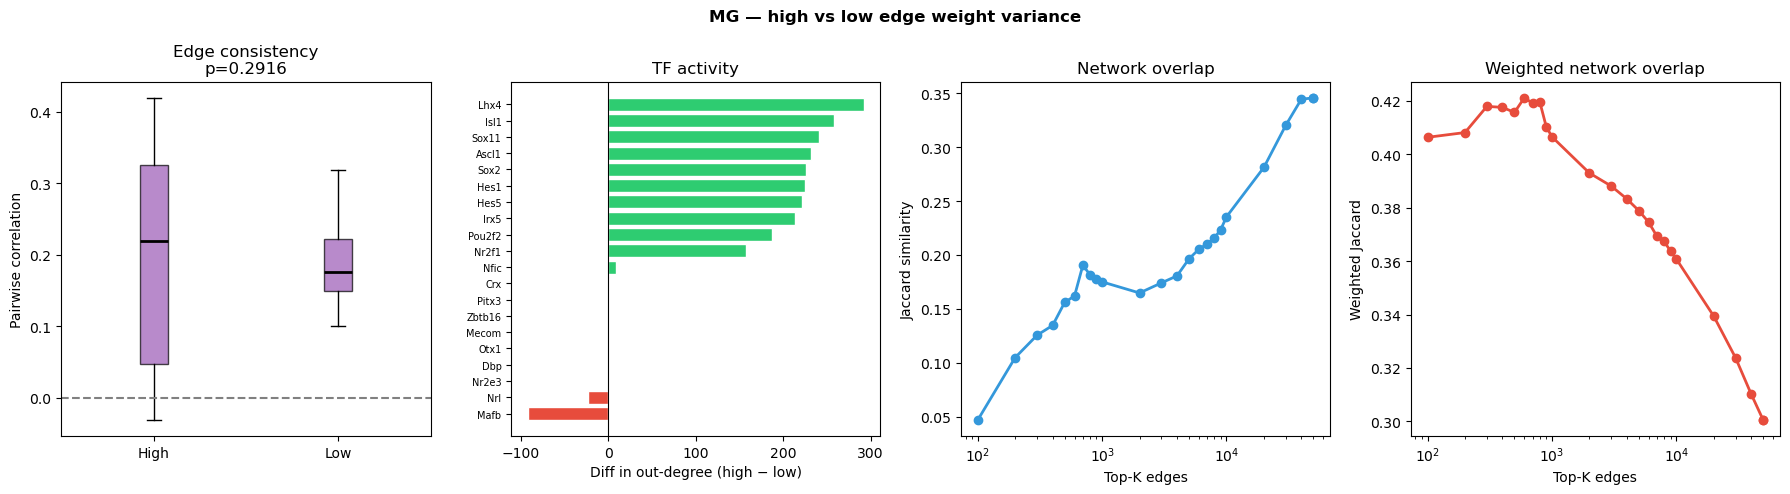


Cell type: RPC1
  High edge variance cells: 10, mean=1.88e-08
  Low edge variance cells : 10, mean=1.54e-08
  Non-zero edges — high: 84965, low: 75251, cap: 75251


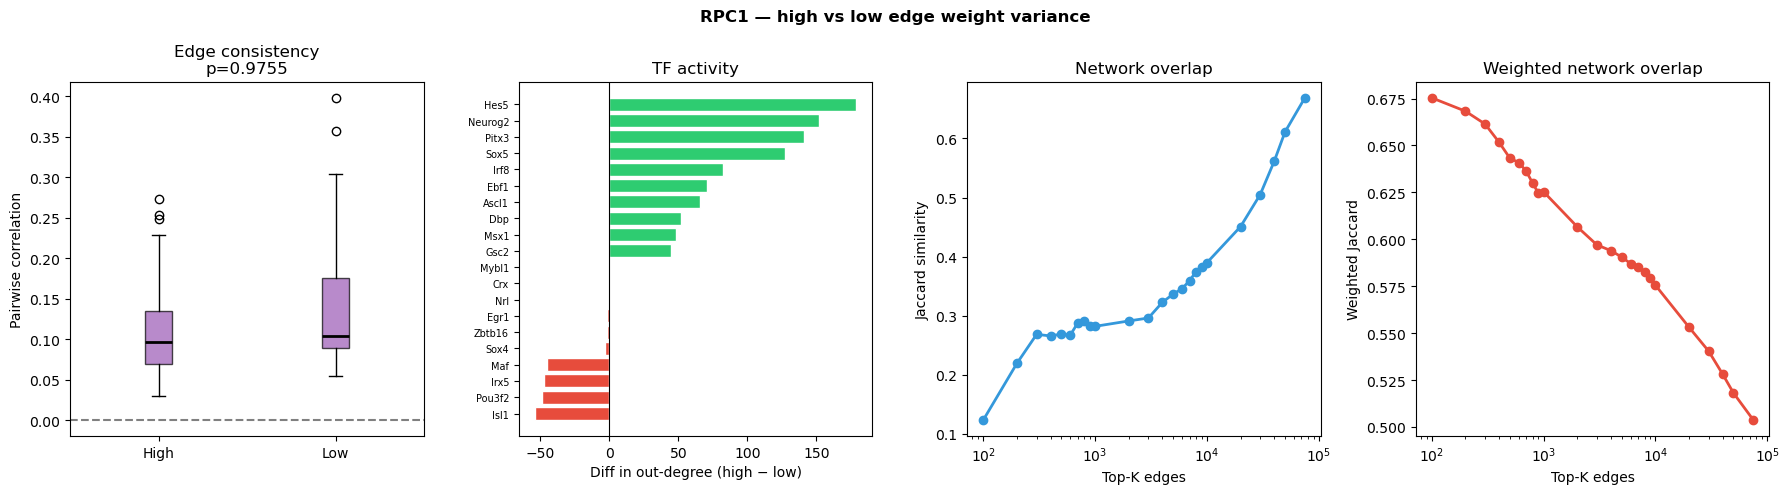


Cell type: RPC2
  High edge variance cells: 10, mean=1.91e-08
  Low edge variance cells : 10, mean=1.50e-08
  Non-zero edges — high: 88306, low: 60667, cap: 60667


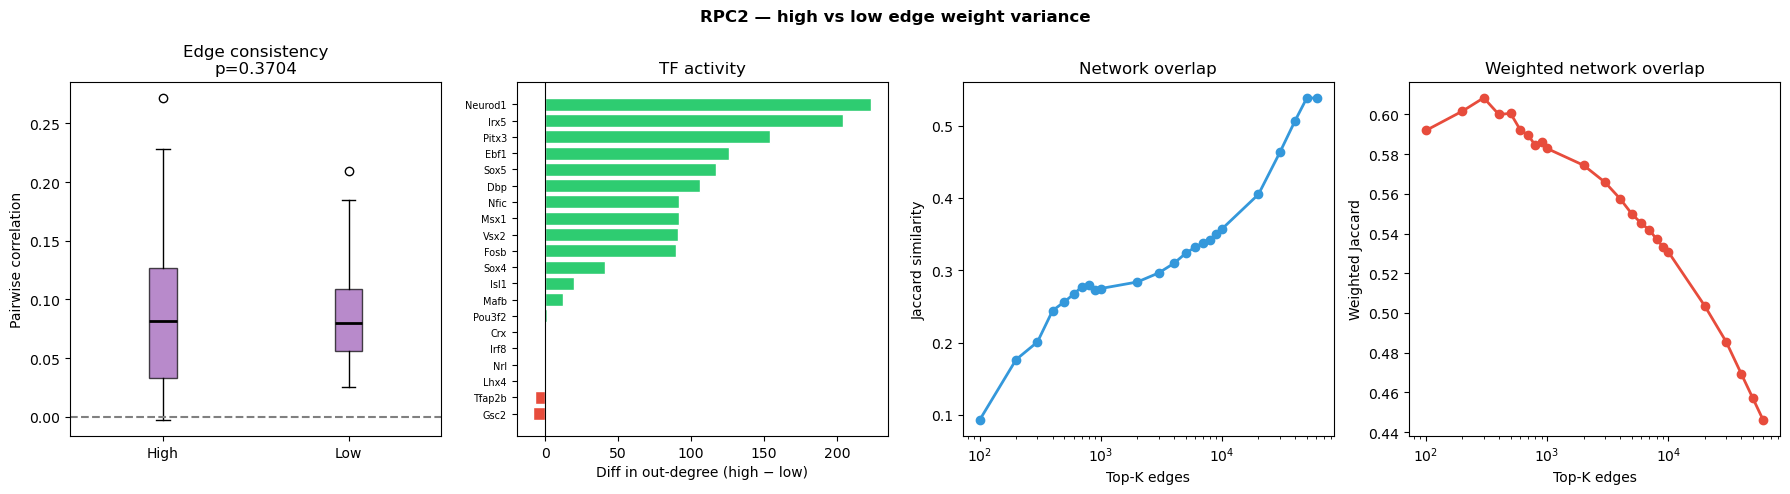


Cell type: RPC3
  High edge variance cells: 10, mean=2.18e-08
  Low edge variance cells : 10, mean=1.45e-08
  Non-zero edges — high: 98358, low: 81921, cap: 81921


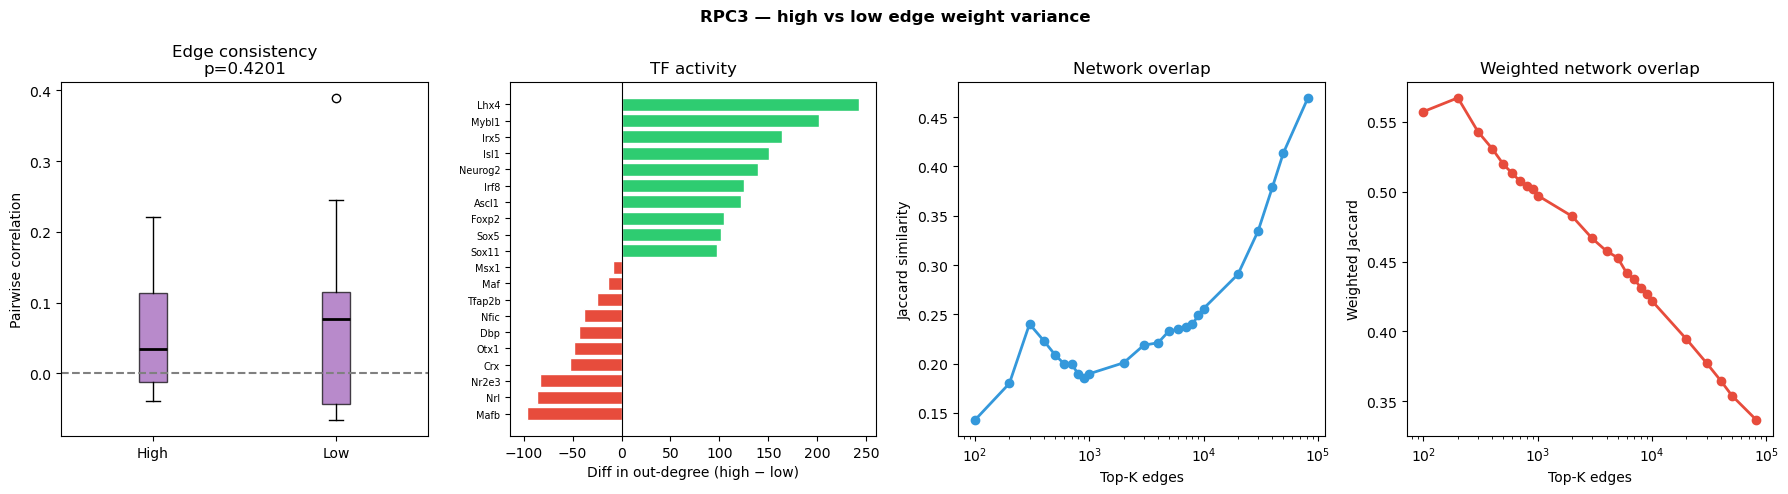

In [50]:
MATCHED_TYPES = ["MG", "RPC1", "RPC2", "RPC3"]

for ct in MATCHED_TYPES:
    print(f"\n{'='*50}")
    print(f"Cell type: {ct}")

    ct_mask = (cell_type == ct).values
    ct_edge_var = mean_edge_var[ct_mask]
    ct_idx      = np.where(ct_mask)[0]

    q_high = np.quantile(ct_edge_var, 0.90)
    q_low  = np.quantile(ct_edge_var, 0.10)

    high_idx = ct_idx[ct_edge_var >= q_high]
    low_idx  = ct_idx[ct_edge_var <= q_low]

    print(f"  High edge variance cells: {len(high_idx)}, mean={ct_edge_var[ct_edge_var >= q_high].mean():.2e}")
    print(f"  Low edge variance cells : {len(low_idx)}, mean={ct_edge_var[ct_edge_var <= q_low].mean():.2e}")

    ct_high_nets = networks[high_idx]
    ct_low_nets  = networks[low_idx]
    ct_high_mean = ct_high_nets.mean(axis=0)
    ct_low_mean  = ct_low_nets.mean(axis=0)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"{ct} — high vs low edge weight variance", fontweight="bold")

    WEIGHT_THRESHOLD = 0.0
    ct_high_corrs = pairwise_correlations(ct_high_nets, threshold=WEIGHT_THRESHOLD)
    ct_low_corrs  = pairwise_correlations(ct_low_nets,  threshold=WEIGHT_THRESHOLD)
    stat, pval = stats.mannwhitneyu(ct_high_corrs, ct_low_corrs, alternative="greater")
    p_str = f"{pval:.2e}" if pval < 0.0001 else f"{pval:.4f}"

    axes[0].boxplot([ct_high_corrs, ct_low_corrs],
                    tick_labels=["High", "Low"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#9b59b6", alpha=0.7),
                    medianprops=dict(color="black", linewidth=2))
    axes[0].set_ylabel("Pairwise correlation")
    axes[0].set_title(f"Edge consistency\np={p_str}")
    axes[0].axhline(0, color="grey", linestyle="--")

    ct_tf = []
    for tf in tf_genes:
        if tf not in gene_to_idx:
            continue
        i = gene_to_idx[tf]
        ct_tf.append({
            "TF":   tf,
            "diff": (ct_high_mean[:, i] > 0).sum() - (ct_low_mean[:, i] > 0).sum(),
        })

    ct_tf_df  = pd.DataFrame(ct_tf).sort_values("diff", ascending=False)
    plot_ct   = pd.concat([ct_tf_df.head(10), ct_tf_df.tail(10)])
    colors_ct = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_ct["diff"]]

    axes[1].barh(range(len(plot_ct)), plot_ct["diff"].values,
                 color=colors_ct, edgecolor="white")
    axes[1].set_yticks(range(len(plot_ct)))
    axes[1].set_yticklabels(plot_ct["TF"].values, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Diff in out-degree (high − low)")
    axes[1].set_title("TF activity")

    high_nonzero = (ct_high_mean > 0).sum()
    low_nonzero  = (ct_low_mean > 0).sum()
    max_k = min(high_nonzero, low_nonzero)
    print(f"  Non-zero edges — high: {high_nonzero}, low: {low_nonzero}, cap: {max_k}")

    top_ks = [k for k in [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000, 30000, 40000, 50000] if k <= max_k]
    top_ks.append(max_k)
    top_ks = sorted(set(top_ks))

    jaccards = [jaccard(binarise(ct_high_mean, top_k=k),
                        binarise(ct_low_mean,  top_k=k)) for k in top_ks]

    axes[2].plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Top-K edges")
    axes[2].set_ylabel("Jaccard similarity")
    axes[2].set_title("Network overlap")

    top_ks   = [k for k in [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000, 30000, 40000, 50000] if k <= max_k]
    top_ks.append(max_k)
    top_ks   = sorted(set(top_ks))

    wjaccards = [weighted_jaccard_topk(ct_high_mean, ct_low_mean, k) for k in top_ks]

    axes[3].plot(top_ks, wjaccards, marker="o", color="#e74c3c", linewidth=2)
    axes[3].set_xscale("log")
    axes[3].set_xlabel("Top-K edges")
    axes[3].set_ylabel("Weighted Jaccard")
    axes[3].set_title("Weighted network overlap")

    plt.tight_layout()
    plt.savefig(f"edgevar_{ct}_comparison.png", dpi=150)
    plt.show()
    plt.show()

In [51]:
oob_var_df = pd.DataFrame({
    "oob_r2":    cell_r2.values,
    "cell_type": cell_type.values,
})

summary = oob_var_df.groupby("cell_type")["oob_r2"].agg(["count", "mean", "std", "min", "max"])
print(summary)

           count      mean       std       min       max
cell_type                                               
MG           100 -0.119482  0.017887 -0.152509 -0.077007
RPC1         100 -0.101505  0.024714 -0.137158 -0.012543
RPC2         100 -0.106251  0.025979 -0.141105 -0.021468
RPC3         100 -0.120990  0.016358 -0.149937 -0.063044


C:\Users\Edi\AppData\Local\Temp\ipykernel_34588\399407229.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = oob_var_df.groupby("cell_type")["oob_r2"].agg(["count", "mean", "std", "min", "max"])



Cell type: MG
  High OOB R$^2$ cells: 10, mean=-0.0880
  Low OOB R$^2$ cells : 10, mean=-0.1468
  Non-zero edges — high: 71169, low: 65444, cap: 65444


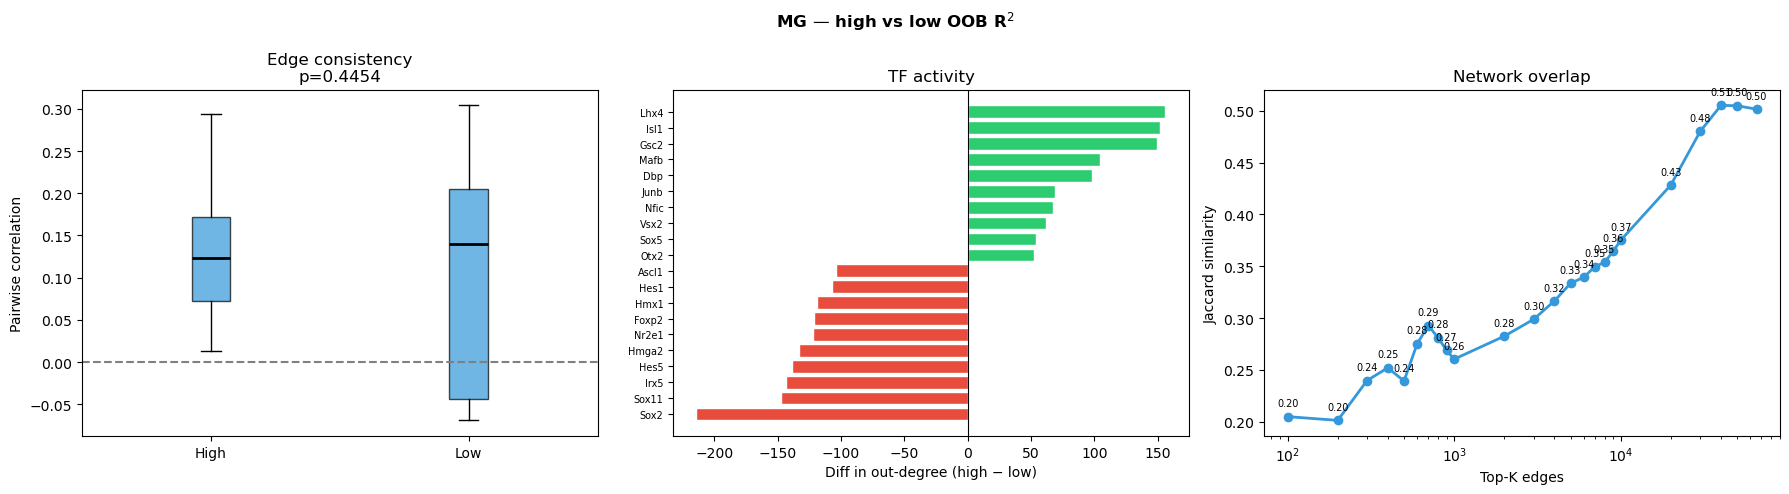


Cell type: RPC1
  High OOB R$^2$ cells: 10, mean=-0.0476
  Low OOB R$^2$ cells : 10, mean=-0.1311
  Non-zero edges — high: 85846, low: 74687, cap: 74687


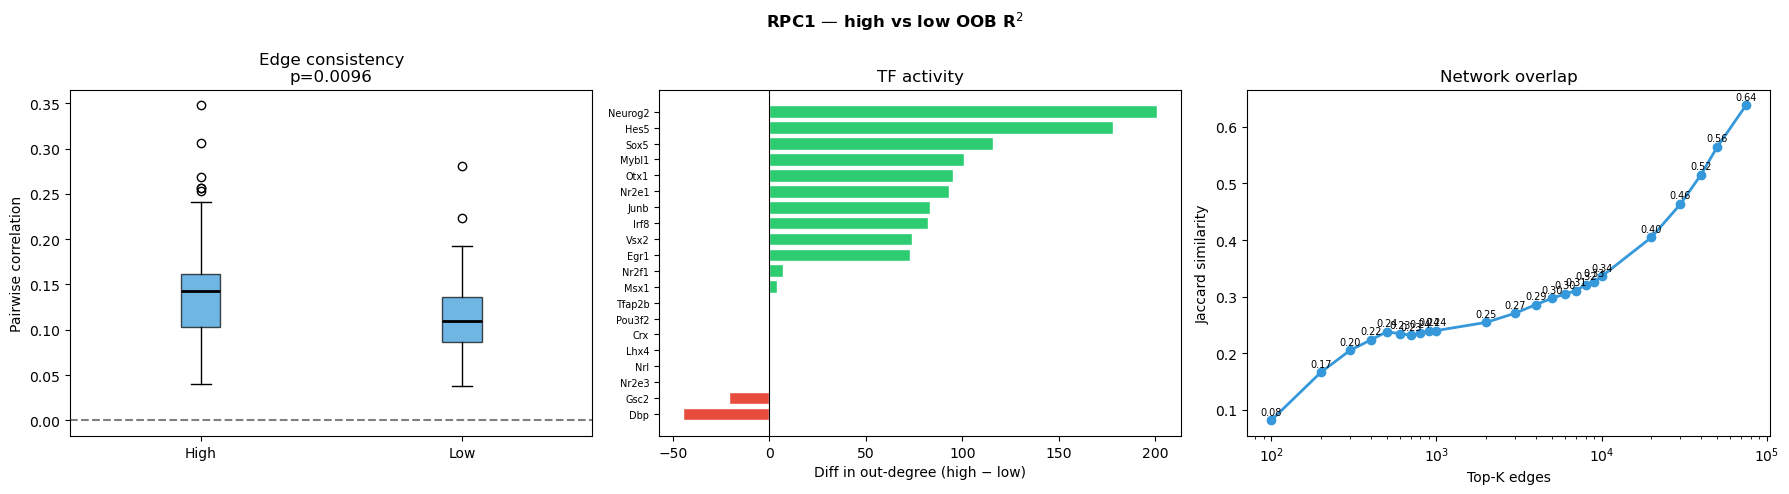


Cell type: RPC2
  High OOB R$^2$ cells: 10, mean=-0.0480
  Low OOB R$^2$ cells : 10, mean=-0.1357
  Non-zero edges — high: 85428, low: 63062, cap: 63062


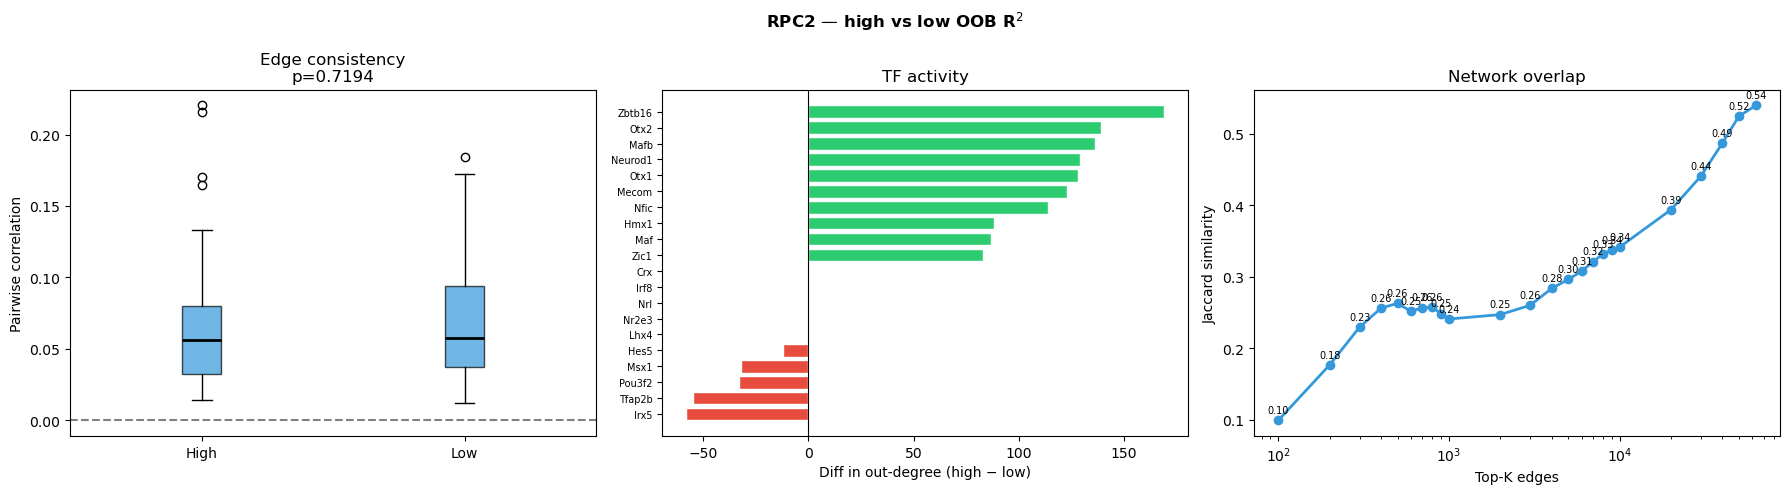


Cell type: RPC3
  High OOB R$^2$ cells: 10, mean=-0.0886
  Low OOB R$^2$ cells : 10, mean=-0.1447
  Non-zero edges — high: 108610, low: 82827, cap: 82827


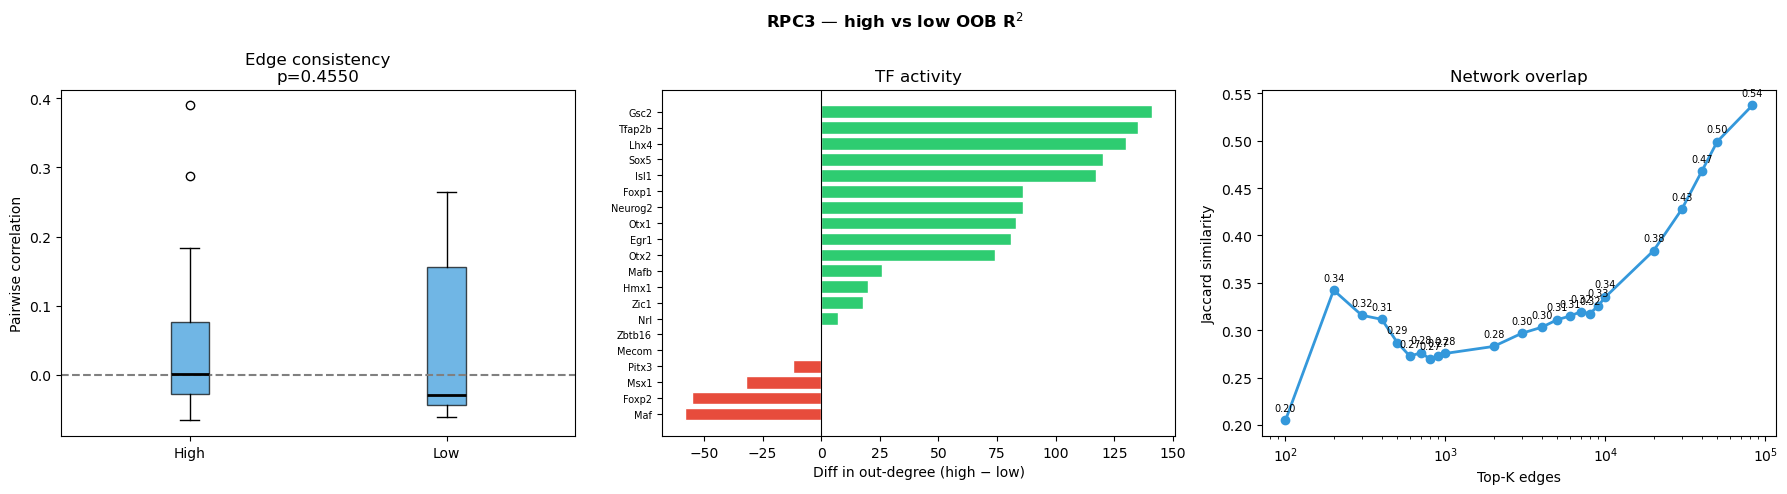

In [52]:
MATCHED_TYPES = ["MG", "RPC1", "RPC2", "RPC3"]

for ct in MATCHED_TYPES:
    print(f"\n{'='*50}")
    print(f"Cell type: {ct}")

    ct_mask = (cell_type == ct).values
    ct_r2   = cell_r2.values[ct_mask]
    ct_idx  = np.where(ct_mask)[0]

    q_high = np.quantile(ct_r2, 0.90)
    q_low  = np.quantile(ct_r2, 0.10)

    high_idx = ct_idx[ct_r2 >= q_high]
    low_idx  = ct_idx[ct_r2 <= q_low]

    print(f"  High OOB R$^2$ cells: {len(high_idx)}, mean={ct_r2[ct_r2 >= q_high].mean():.4f}")
    print(f"  Low OOB R$^2$ cells : {len(low_idx)}, mean={ct_r2[ct_r2 <= q_low].mean():.4f}")

    ct_high_nets = networks[high_idx]
    ct_low_nets  = networks[low_idx]
    ct_high_mean = ct_high_nets.mean(axis=0)
    ct_low_mean  = ct_low_nets.mean(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{ct} — high vs low OOB R$^2$", fontweight="bold")

    WEIGHT_THRESHOLD = 0.0
    ct_high_corrs = pairwise_correlations(ct_high_nets, threshold=WEIGHT_THRESHOLD)
    ct_low_corrs  = pairwise_correlations(ct_low_nets,  threshold=WEIGHT_THRESHOLD)
    stat, pval = stats.mannwhitneyu(ct_high_corrs, ct_low_corrs, alternative="greater")
    p_str = f"{pval:.2e}" if pval < 0.0001 else f"{pval:.4f}"

    axes[0].boxplot([ct_high_corrs, ct_low_corrs],
                    tick_labels=["High", "Low"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#3498db", alpha=0.7),
                    medianprops=dict(color="black", linewidth=2))
    axes[0].set_ylabel("Pairwise correlation")
    axes[0].set_title(f"Edge consistency\np={p_str}")
    axes[0].axhline(0, color="grey", linestyle="--")

    ct_tf = []
    for tf in tf_genes:
        if tf not in gene_to_idx:
            continue
        i = gene_to_idx[tf]
        ct_tf.append({
            "TF":   tf,
            "diff": (ct_high_mean[:, i] > 0).sum() - (ct_low_mean[:, i] > 0).sum(),
        })

    ct_tf_df  = pd.DataFrame(ct_tf).sort_values("diff", ascending=False)
    plot_ct   = pd.concat([ct_tf_df.head(10), ct_tf_df.tail(10)])
    colors_ct = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_ct["diff"]]

    axes[1].barh(range(len(plot_ct)), plot_ct["diff"].values,
                 color=colors_ct, edgecolor="white")
    axes[1].set_yticks(range(len(plot_ct)))
    axes[1].set_yticklabels(plot_ct["TF"].values, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Diff in out-degree (high − low)")
    axes[1].set_title("TF activity")

    high_nonzero = (ct_high_mean > 0).sum()
    low_nonzero  = (ct_low_mean > 0).sum()
    max_k = min(high_nonzero, low_nonzero)
    print(f"  Non-zero edges — high: {high_nonzero}, low: {low_nonzero}, cap: {max_k}")

    top_ks = [k for k in [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000, 30000, 40000, 50000] if k <= max_k]
    top_ks.append(max_k)
    top_ks = sorted(set(top_ks))

    jaccards = [jaccard(binarise(ct_high_mean, top_k=k),
                        binarise(ct_low_mean,  top_k=k)) for k in top_ks]

    axes[2].plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Top-K edges")
    axes[2].set_ylabel("Jaccard similarity")
    axes[2].set_title("Network overlap")
    for k, j in zip(top_ks, jaccards):
        axes[2].text(k, j + 0.01, f"{j:.2f}", ha="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(f"oobr2_{ct}_comparison.png", dpi=150)
    plt.show()

In [53]:
for ct in MATCHED_TYPES:
    ct_mask = (cell_type == ct).values

    ct_r2        = cell_r2.values[ct_mask]
    ct_precision = mean_pr["precision"].values[ct_mask]
    ct_recall    = mean_pr["recall"].values[ct_mask]

    r_p, p_p = stats.spearmanr(ct_r2, ct_precision)
    r_r, p_r = stats.spearmanr(ct_r2, ct_recall)

    print(f"{ct}:")
    print(f"  OOB R$^2$ vs precision: r={r_p:.4f}, p={p_p:.4f}")
    print(f"  OOB R$^2$ vs recall   : r={r_r:.4f}, p={p_r:.4f}")
    print()

MG:
  OOB R$^2$ vs precision: r=0.2492, p=0.0124
  OOB R$^2$ vs recall   : r=0.5187, p=0.0000

RPC1:
  OOB R$^2$ vs precision: r=0.0263, p=0.7951
  OOB R$^2$ vs recall   : r=0.5793, p=0.0000

RPC2:
  OOB R$^2$ vs precision: r=-0.1284, p=0.2029
  OOB R$^2$ vs recall   : r=0.6115, p=0.0000

RPC3:
  OOB R$^2$ vs precision: r=0.0950, p=0.3472
  OOB R$^2$ vs recall   : r=0.4727, p=0.0000



In [54]:
for ct in MATCHED_TYPES:
    ct_mask = (cell_type == ct).values

    ct_edge_var  = mean_edge_var[ct_mask]
    ct_precision = mean_pr["precision"].values[ct_mask]
    ct_recall    = mean_pr["recall"].values[ct_mask]

    r_p, p_p = stats.spearmanr(ct_edge_var, ct_precision)
    r_r, p_r = stats.spearmanr(ct_edge_var, ct_recall)

    print(f"{ct}:")
    print(f"  Edge variance vs precision: r={r_p:.4f}, p={p_p:.4f}")
    print(f"  Edge variance vs recall   : r={r_r:.4f}, p={p_r:.4f}")
    print()

MG:
  Edge variance vs precision: r=0.6156, p=0.0000
  Edge variance vs recall   : r=0.6930, p=0.0000

RPC1:
  Edge variance vs precision: r=-0.1385, p=0.1693
  Edge variance vs recall   : r=0.0459, p=0.6505

RPC2:
  Edge variance vs precision: r=-0.0302, p=0.7658
  Edge variance vs recall   : r=0.6236, p=0.0000

RPC3:
  Edge variance vs precision: r=0.3906, p=0.0001
  Edge variance vs recall   : r=0.3043, p=0.0021

